Episode 001/700 | StartTime 2026-03-12 05:42:40 | MaxQChange 2.900000 | QueueLength 1842 | Reward     -5377.00 | Epsilon 0.992 | EpStates  168 | NewStates  168 | TotalStates   168
Episode 002/700 | StartTime 2026-03-12 05:45:53 | MaxQChange 2.700000 | QueueLength 2054 | Reward     -6492.00 | Epsilon 0.984 | EpStates  152 | NewStates   90 | TotalStates   258
Episode 003/700 | StartTime 2026-03-12 05:49:07 | MaxQChange 2.600000 | QueueLength 1872 | Reward     -5636.00 | Epsilon 0.976 | EpStates  157 | NewStates   66 | TotalStates   324
Episode 004/700 | StartTime 2026-03-12 05:52:24 | MaxQChange 1.300000 | QueueLength 1398 | Reward     -3732.00 | Epsilon 0.968 | EpStates  100 | NewStates   11 | TotalStates   335
Episode 005/700 | StartTime 2026-03-12 05:55:44 | MaxQChange 1.750349 | QueueLength 1486 | Reward     -3958.00 | Epsilon 0.960 | EpStates  119 | NewStates   22 | TotalStates   357
Episode 006/700 | StartTime 2026-03-12 05:59:27 | MaxQChange 1.953402 | QueueLength 1562 | Reward   

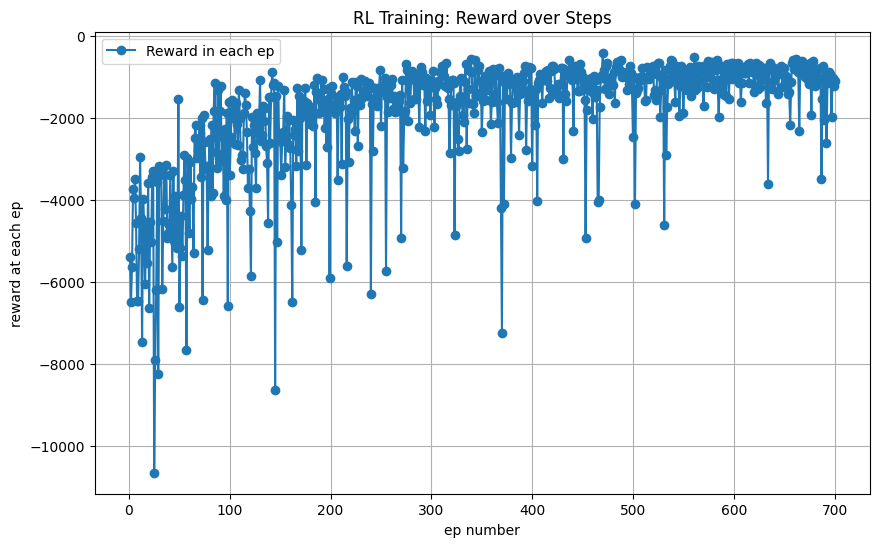

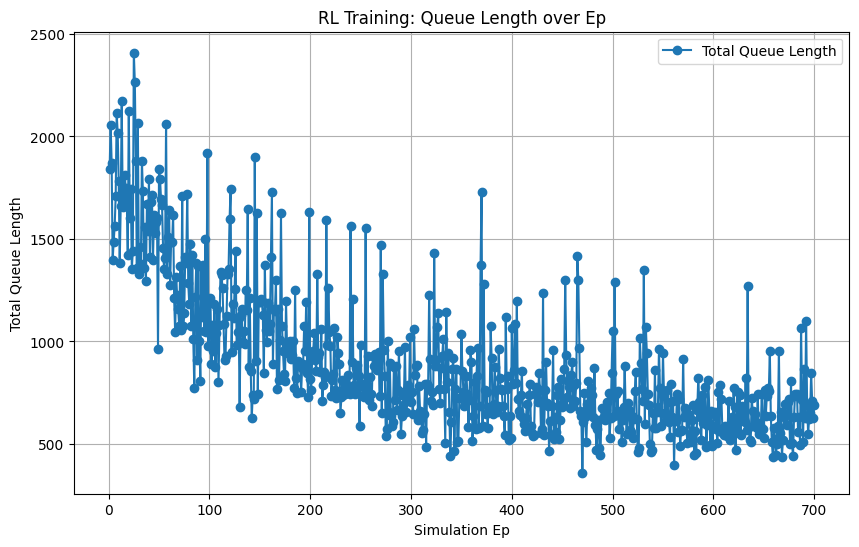

In [1]:
# this code is the best one only problem is one phase with leat queue can be neleglegted for many step
import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\best-scenario\scenario\sumo\berlin.sumocfg"

Ac =[0,2,4,6]

episode = 700
max_step = 1000

alpha = 0.05
gamma = 0.92

max_green = 30
min_green = 5
max_red = 3
n=650
e = 1
e_min = 0.005
e_decay = (0.005)**(1/n)
green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0
c=0

Q = defaultdict(lambda: np.zeros(4))

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

LANES_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
LANES_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
LANES_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
LANES_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']


def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def queueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = queueLength(LANES_A)
    B = queueLength(LANES_B)
    C = queueLength(LANES_C)
    D = queueLength(LANES_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)

def e_greedy(state,e):
    if random.random()<e:
        return random.randint(0, 3)
    return int(np.argmax(Q[state]))

def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)

def Q_value(old_state, action, reward, new_state):

    old_q = Q[old_state][action]

    target = reward + gamma * np.max(Q[new_state])

    Q[old_state][action] += alpha * (target - old_q)

    new_q = Q[old_state][action]

    return abs(new_q - old_q)


def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False
    
queue_history =[]
ep_history = []
reward_history = []
all_states = set()
for ep in range(1, episode + 1):
    ep_start_time = datetime.now(pytz.timezone("Asia/Kolkata")).strftime("%Y-%m-%d %H:%M:%S")
    ep_history.append(ep)
    
    
    traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
    total_ph = len(traci.trafficlight.getAllProgramLogics(tls_id)[0].phases)
    phase_prev = traci.trafficlight.getPhase(tls_id)
    
    ep_reward = 0
    ep_states = set()    
    new_states = set()  
    total_ep_queue = 0

    max_q_change = 0
    step =0
    while step < max_step:
        old_state = get_state(tls_id)
        action = e_greedy(old_state, e)
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)
        total_ep_queue+= sum(old_state[:4])
        
        if(mustSwitch(phase,duration)):
            if phase in green_ph:
                if(action == 0 ):
                    action =  random.randint(1, 3)
                traci.trafficlight.setPhase(tls_id, phase+1)
                traci.trafficlight.setPhaseDuration(tls_id, 3)
                for i in range(0,3):
                    traci.simulationStep()
                step = step + 3 
                nextPhase = NextPhase(action,phase)
                traci.trafficlight.setPhase(tls_id,nextPhase)
                traci.trafficlight.setPhaseDuration(tls_id, 31)
            
            elif phase in red_ph:
                action = 1
                traci.trafficlight.setPhase(tls_id, phase+1)
                
            phase = current_phase(tls_id)
            duration = traci.trafficlight.getSpentDuration(tls_id)
            if(phase in green_ph):
                traci.trafficlight.setPhaseDuration(tls_id, 31)
            else:
                traci.trafficlight.setPhaseDuration(tls_id, 3)
            
        elif(canRLAct(phase,duration)):
            if(action == 0):
                traci.trafficlight.setPhase(tls_id, phase)
                traci.trafficlight.setPhaseDuration(tls_id, 31)
            else:
                traci.trafficlight.setPhase(tls_id, phase+1)
                traci.trafficlight.setPhaseDuration(tls_id, 3)
                for i in range(0,3):
                    traci.simulationStep()
                step = step + 3 
                nextPhase = NextPhase(action,phase)
                traci.trafficlight.setPhase(tls_id,nextPhase)
                traci.trafficlight.setPhaseDuration(tls_id, 31)

        traci.simulationStep()
        step += 1

        phase_curr = traci.trafficlight.getPhase(tls_id)
        new_state = get_state(tls_id)
        reward = get_reward(new_state)
        delta = Q_value(old_state, action, reward, new_state)
        
        if delta > max_q_change:
            max_q_change = delta
        
        ep_reward+=reward
        ep_states.add(old_state)
        if old_state not in all_states:
            new_states.add(old_state)
            all_states.add(old_state)
            
    traci.close()
    e = max(e_min, e * e_decay)
    reward_history.append(ep_reward)
    queue_history.append(total_ep_queue)
    print( f"Episode {ep:03d}/{episode} | "f"StartTime {ep_start_time} | "f"MaxQChange {max_q_change:.6f} | "f"QueueLength {total_ep_queue} | "f"Reward {ep_reward:12.2f} | "f"Epsilon {e:.3f} | "f"EpStates {len(ep_states):4d} | "f"NewStates {len(new_states):4d} | "f"TotalStates {len(all_states):5d}")

with open("model_version1.pkl", "wb") as f:
    pickle.dump(dict(Q), f)

print("\nTraining finished")
print(f"Total learned states: {len(all_states)}")        
plt.figure(figsize=(10, 6))
plt.plot(ep_history, reward_history, marker='o', linestyle='-', label="Reward in each ep")
plt.xlabel("ep number")
plt.ylabel("reward at each ep")
plt.title("RL Training: Reward over Steps")
plt.legend()
plt.grid(True) 
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(ep_history, queue_history, marker='o', linestyle='-', label="Total Queue Length")
plt.xlabel("Simulation Ep")
plt.ylabel("Total Queue Length")
plt.title("RL Training: Queue Length over Ep")
plt.legend()
plt.grid(True)
plt.show()